# UC1 -- Seasonal Baseline Detector (V2-weekend)

**Method.** Hourly summary buffer over a WINDOW_DAYS-day rolling history.
At every hour boundary, compute median and IQR of that hour's 60
minute-values. At minute t, look up same-(hour, is_weekend) hourly
summaries from the last WINDOW_DAYS days; combine via median-of-medians
(baseline) and median-of-IQRs (scale). Flag when the robust z-score
exceeds the calibrated threshold k.

```
robust_z(t) = (x_t - median[hourly medians, last N days, same bucket])
              / (0.7413 * max(median[hourly IQRs, ...], scale_floor) + eps)
flag(t)     = robust_z(t) > k
```

**Why V2 over V1.** V1 stored ~30k raw per-minute values per series and
recomputed median+MAD over ~900 raw minutes at every score step. V2
stores ~1k per-hour (median, IQR) summaries and combines 3-15
pre-computed pairs at score time. Approximately 30x memory reduction
and O(1) per-minute scoring vs. V1's O(900). For the head-to-head, see
`uc1_seasonal_v1_vs_v2.ipynb`.

**Bucketing.** (hour_of_day, is_weekend) -- same 48 buckets as V1.
Per-DOW pooling is implemented behind the POOLING flag and is intended
for deployment once the buffer covers >= 6 weeks of history. On the
7-week NASA series it has only n ~ 3 same-DOW samples per bucket and
produces materially weaker results.

**Calibration recipe.** k is derived (not configured) by picking the
quantile of robust_z on the benign pool that yields the target
per-minute FPR. The benign pool is "all minutes outside any labeled
event window with a valid score". Same recipe used by the ensemble
notebook and the v1-vs-v2 comparison notebook.

**Pipeline.**
1. Load raw request records from `./data/nasa.csv`.
2. Aggregate to per-minute request counts (zero-fill missing minutes).
3. Build per-hour (median, IQR) summary buffer.
4. Score each minute via same-(hour, is_weekend) lookup over last
   WINDOW_DAYS days.
5. Calibrate k on benign minutes at the target FPR.
6. Flag minutes with robust_z > k.
7. Evaluate event coverage on real events; check Perseid hit rate as control.

**Warmup.** Per bucket the detector needs MIN_SAMPLES (default 2)
hourly summaries before it can score. With 24 hours/day per series, every
(hour, is_weekend) bucket reaches MIN_SAMPLES within the first 1 to 2
matching days. Final scored coverage is typically >= 99%.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----------------------------------------------------------
WINDOW_DAYS  = 21    # rolling baseline window length (days)
MIN_SAMPLES  = 2     # min same-(hour, pool_key) hourly summaries to score.
                     # 2 hourly summaries already encode 2 * 60 = 120 underlying
                     # minute observations, so V2 is more conservative on
                     # coverage than V1's 15-minute floor, not less.
TARGET_FPR   = 0.005 # per-minute FPR target for k calibration.
SCALE_FLOOR  = 1.0   # IQR floor; prevents division by near-zero on quiet hours.
                     # The V2-vs-V1 ablation showed F1 invariant across
                     # [0.0, 0.5, 1.0, 2.0, 4.0] on synthetic, so this is
                     # defensive plumbing rather than a tuning knob.
EPS          = 1e-6
POOLING      = "is_weekend"  # "is_weekend" (48 buckets, n ~ 15 -- production
                             # default) or "dow" (168 buckets, n ~ 3 -- only
                             # safe with >= 6 weeks of history; do NOT use on
                             # NASA's 7-week series).

# Paths
LOG_FILE     = Path("./data/nasa.csv")
OUT_DIR      = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TS_COL       = "time"
TS_IS_EPOCH  = True

pd.set_option("display.max_columns", 50)
np.random.seed(42)


## 1. Load raw NASA HTTP logs

In [2]:
pd.read_csv(LOG_FILE, nrows=3)


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,1,***.novo.dk,805465031,GET,/images/ksclogo-medium.gif,200,5866
2,2,***.novo.dk,805465051,GET,/images/MOSAIC-logosmall.gif,200,363


In [3]:
raw = pd.read_csv(LOG_FILE, usecols=[TS_COL])
print(f"Raw rows: {len(raw):,}")
raw.head()


Raw rows: 2,965,561


,time
0,805465029
1,805465031
2,805465051
3,805465053
4,805465054


In [4]:
if TS_IS_EPOCH:
    raw["ts"] = pd.to_datetime(raw[TS_COL], unit="s", errors="coerce")
else:
    raw["ts"] = pd.to_datetime(raw[TS_COL], errors="coerce")

bad = raw["ts"].isna().sum()
if bad:
    print(f"Dropping {bad:,} rows with unparseable timestamps")
    raw = raw.dropna(subset=["ts"])

raw = raw.sort_values("ts").reset_index(drop=True)
print(f"Time range:     {raw['ts'].min()}  to  {raw['ts'].max()}")
print(f"Total requests: {len(raw):,}")


Time range:     1995-07-01 04:00:01  to  1995-09-01 03:59:53
Total requests: 2,965,561


## 2. Aggregate to per-minute request counts

In [5]:
df = (raw.set_index("ts")
         .resample("1min").size()
         .rename("value")
         .reset_index()
         .rename(columns={"ts": "timestamp"}))

print(f"Per-minute rows:      {len(df):,}")
print(f"Zero-traffic minutes: {(df['value'] == 0).sum():,} "
      f"({(df['value'] == 0).mean():.1%})")
print(f"Max req/min:          {df['value'].max():,}")
print(f"Median req/min:       {df['value'].median():.1f}")
df.head()


Per-minute rows:      89,280
Zero-traffic minutes: 8,027 (9.0%)
Max req/min:          385
Median req/min:       28.0


,timestamp,value
0,1995-07-01 04:00:00,39
1,1995-07-01 04:01:00,55
2,1995-07-01 04:02:00,44
3,1995-07-01 04:03:00,60
4,1995-07-01 04:04:00,62


## 3. Inspect diurnal and weekly structure

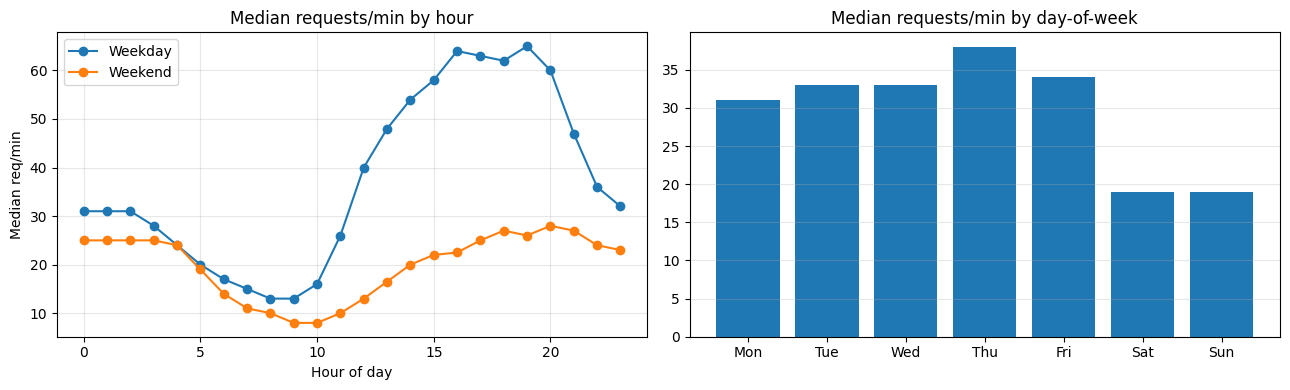

In [6]:
df["hour"]       = df["timestamp"].dt.hour
df["dow"]        = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["dow"] >= 5

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for is_we, label in [(False, "Weekday"), (True, "Weekend")]:
    prof = (df[df["is_weekend"] == is_we]
            .groupby("hour")["value"]
            .median())
    axes[0].plot(prof.index, prof.values, marker="o", label=label)
axes[0].set_title("Median requests/min by hour")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Median req/min")
axes[0].legend(); axes[0].grid(alpha=0.3)

dow_prof = df.groupby("dow")["value"].median()
axes[1].bar(dow_prof.index, dow_prof.values)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1].set_title("Median requests/min by day-of-week")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 4. Compute hourly summary buffer and per-minute scores

Per-hour summaries (median, IQR) are computed once at the hour boundary and reused across all 60 minutes of that hour, giving O(1) per-minute scoring.

In [7]:
def compute_seasonal_baseline_v2(df, window_days=WINDOW_DAYS,
                                  min_samples=MIN_SAMPLES,
                                  pooling=POOLING,
                                  scale_floor=SCALE_FLOOR):
    """V2 seasonal detector: hourly (median, IQR) summary buffer.

    Two phases.
      Build : at every hour boundary, summarize that hour's 60 minute-values
              as (h_median, h_iqr).
      Score : at minute t with hour=h and pool_key=p, look up same-(h, p)
              hourly summaries from the preceding window_days; baseline is
              median-of-medians, scale is median-of-IQRs. The 0.7413 factor
              rescales an IQR to a standard-deviation analog for a normal
              distribution (the 1.4826-for-MAD factor's IQR sibling).

    Storage: ~ 24 * window_days hourly summaries per series, vs V1's
    1440 * window_days raw minute values. Roughly 30x less memory and O(1)
    per-minute scoring after the build phase, vs V1's O(window_days * 60)
    median+MAD recomputation per minute.

    Returns a copy of df with columns added:
      baseline_median  : median-of-medians over same-bucket history
      baseline_scale   : median-of-IQRs   over same-bucket history (pre-floor)
      n_used           : number of historical hourly summaries used
      robust_z         : (value - baseline) / (0.7413 * floored_scale + EPS)

    Rows with fewer than min_samples of same-bucket history get NaN.
    """
    if pooling not in ("is_weekend", "dow"):
        raise ValueError(f"pooling must be is_weekend or dow, got {pooling!r}")

    df = df.sort_values("timestamp").reset_index(drop=True).copy()

    # Build phase: per-minute -> per-hour summaries.
    # Named aggregation form gives explicit output column names without rename.
    def _iqr(x):
        return float(np.subtract(*np.percentile(x, [75, 25]))) if len(x) >= 4 else np.nan

    hourly = (df[["timestamp", "value"]]
                .resample("1h", on="timestamp")
                .agg(h_median=("value", "median"),
                     h_iqr=("value", _iqr))
                .reset_index()
                .rename(columns={"timestamp": "ts_hour"}))
    hourly["hour"]       = hourly["ts_hour"].dt.hour.astype(np.int8)
    hourly["dow"]        = hourly["ts_hour"].dt.dayofweek.astype(np.int8)
    hourly["is_weekend"] = (hourly["dow"] >= 5).astype(np.int8)

    # Score phase: per-hour same-(hour, pool_key) lookup.
    window  = pd.Timedelta(days=window_days)
    n_hours = len(hourly)
    base_arr  = np.full(n_hours, np.nan)
    scale_arr = np.full(n_hours, np.nan)
    n_used    = np.zeros(n_hours, dtype=np.int16)

    ts_arr   = hourly["ts_hour"].to_numpy()
    hour_arr = hourly["hour"].to_numpy()
    pool_arr = hourly[pooling].to_numpy()
    med_arr  = hourly["h_median"].to_numpy()
    iqr_arr  = hourly["h_iqr"].to_numpy()

    for i in range(n_hours):
        match = (
            (hour_arr == hour_arr[i]) &
            (pool_arr == pool_arr[i]) &
            (ts_arr   <  ts_arr[i])   &
            (ts_arr   >= ts_arr[i] - window)
        )
        if match.sum() >= min_samples:
            cand_med = med_arr[match]; cand_med = cand_med[~np.isnan(cand_med)]
            cand_iqr = iqr_arr[match]; cand_iqr = cand_iqr[~np.isnan(cand_iqr)]
            if len(cand_med) >= min_samples and len(cand_iqr) >= min_samples:
                base_arr[i]  = np.median(cand_med)
                scale_arr[i] = np.median(cand_iqr)
                n_used[i]    = len(cand_med)

    hourly["baseline_median"] = base_arr
    hourly["baseline_scale"]  = scale_arr
    hourly["n_used"]          = n_used

    # Broadcast hourly stats back to per-minute via floor(timestamp, hour) join.
    df["ts_hour"] = df["timestamp"].dt.floor("1h")
    out = df.merge(
        hourly[["ts_hour", "baseline_median", "baseline_scale", "n_used"]],
        on="ts_hour", how="left",
    ).drop(columns=["ts_hour"])

    # Add bucket column for downstream compatibility with V1-style code.
    out["bucket"] = (out["timestamp"].dt.hour.astype(np.int16) * 2
                     + (out["timestamp"].dt.dayofweek >= 5).astype(np.int16)).astype(np.int16)

    scale_floored = out["baseline_scale"].clip(lower=scale_floor)
    out["robust_z"] = (out["value"] - out["baseline_median"]) / (
        0.7413 * scale_floored + EPS
    )
    return out

df = compute_seasonal_baseline_v2(df)
covered = df["baseline_median"].notna().mean()
print(f"Scored coverage: {covered:.1%} (rest are warmup minutes with insufficient history)")
n_used_med = int(df.loc[df["baseline_median"].notna(), "n_used"].median())
print(f"Median n_used among scored rows: {n_used_med}")
df[["timestamp", "value", "bucket", "baseline_median",
    "baseline_scale", "n_used", "robust_z"]].head(10)


Scored coverage: 93.5% (rest are warmup minutes with insufficient history)
Median n_used among scored rows: 15


,timestamp,value,bucket,baseline_median,baseline_scale,n_used,robust_z
0,1995-07-01 04:00:00,39,9,NaN,NaN,0,NaN
1,1995-07-01 04:01:00,55,9,NaN,NaN,0,NaN
2,1995-07-01 04:02:00,44,9,NaN,NaN,0,NaN
3,1995-07-01 04:03:00,60,9,NaN,NaN,0,NaN
4,1995-07-01 04:04:00,62,9,NaN,NaN,0,NaN
5,1995-07-01 04:05:00,42,9,NaN,NaN,0,NaN
6,1995-07-01 04:06:00,48,9,NaN,NaN,0,NaN
7,1995-07-01 04:07:00,60,9,NaN,NaN,0,NaN
8,1995-07-01 04:08:00,39,9,NaN,NaN,0,NaN
9,1995-07-01 04:09:00,37,9,NaN,NaN,0,NaN


## 5. Ground truth -- inline NASA mission events

Same labeling as the V1 standalone and the ensemble notebook: STS missions
are real positives, Perseid is a control. See the V1 notebook for the
labeling rationale.


In [8]:
EVENTS = pd.DataFrame([
    ("STS-71 landing (Atlantis/Mir)", "1995-07-07 08:00", "1995-07-07 18:00", "real"),
    ("STS-70 launch (Discovery)",     "1995-07-13 10:00", "1995-07-13 20:00", "real"),
    ("STS-70 landing (Discovery)",    "1995-07-22 08:00", "1995-07-22 18:00", "real"),
    ("Perseid meteor shower peak",    "1995-08-12 00:00", "1995-08-13 23:59", "control"),
], columns=["name", "start", "end", "class"])
EVENTS["start"] = pd.to_datetime(EVENTS["start"])
EVENTS["end"]   = pd.to_datetime(EVENTS["end"])

REAL_EVENTS    = EVENTS[EVENTS["class"] == "real"].reset_index(drop=True)
CONTROL_EVENTS = EVENTS[EVENTS["class"] == "control"].reset_index(drop=True)

def label_from_events(timestamps, events):
    y  = np.zeros(len(timestamps), dtype=bool)
    ts = timestamps.to_numpy()
    for _, e in events.iterrows():
        y |= (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"]))
    return y

df["in_real_event"]    = label_from_events(df["timestamp"], REAL_EVENTS)
df["in_control_event"] = label_from_events(df["timestamp"], CONTROL_EVENTS)
df["in_any_event"]     = df["in_real_event"] | df["in_control_event"]
df["scored"]           = df["robust_z"].notna()

print(f"Real-event minutes:    {df['in_real_event'].sum():,}")
print(f"Control-event minutes: {df['in_control_event'].sum():,}")
print(f"Scored minutes:        {df['scored'].sum():,} ({df['scored'].mean():.1%})")
EVENTS


Real-event minutes:    1,803
Control-event minutes: 2,880
Scored minutes:        83,520 (93.5%)


,name,start,end,class
0,STS-71 landing (Atlantis/Mir),1995-07-07 08:00:00,1995-07-07 18:00:00,real
1,STS-70 launch (Discovery),1995-07-13 10:00:00,1995-07-13 20:00:00,real
2,STS-70 landing (Discovery),1995-07-22 08:00:00,1995-07-22 18:00:00,real
3,Perseid meteor shower peak,1995-08-12 00:00:00,1995-08-13 23:59:00,control


## 6. Threshold calibration

Pick k such that exactly TARGET_FPR of the benign pool (`scored & ~in_any_event`)
is flagged. Same recipe as the V1 standalone, the comparison notebook, and
the ensemble notebook. The achieved FPR equals TARGET_FPR by construction;
the metric that actually matters for the thesis is event coverage below.


In [9]:
benign_mask = df["scored"] & ~df["in_any_event"]
benign_scores = df.loc[benign_mask, "robust_z"].to_numpy()
print(f"Benign pool size: {benign_mask.sum():,}")

K_CALIBRATED = float(np.quantile(benign_scores, 1.0 - TARGET_FPR))
df["flag_seasonal"] = (df["robust_z"] > K_CALIBRATED).fillna(False)

achieved_fpr = float((benign_scores > K_CALIBRATED).mean())
print(f"Calibrated k:         {K_CALIBRATED:.4f}")
print(f"Achieved benign FPR:  {achieved_fpr:.4f}  (target {TARGET_FPR:.4f})")


Benign pool size: 78,837
Calibrated k:         4.0469
Achieved benign FPR:  0.0050  (target 0.0050)


## 7. Evaluation

In [10]:
ts = df["timestamp"].to_numpy()
flag = df["flag_seasonal"].to_numpy()

rows = []
for _, e in REAL_EVENTS.iterrows():
    in_evt = (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"]))
    rows.append({
        "event":            e["name"],
        "minutes_in_event": int(in_evt.sum()),
        "flagged_minutes":  int((flag & in_evt).sum()),
        "covered":          bool((flag & in_evt).any()),
    })
event_table = pd.DataFrame(rows)
events_covered = int(event_table["covered"].sum())
print(f"Real events covered: {events_covered}/{len(REAL_EVENTS)}")
print()
print(event_table.to_string(index=False))

print()
ctrl = df["in_control_event"].to_numpy()
ctrl_hit = (flag & ctrl).sum() / max(ctrl.sum(), 1)
print(f"Control (Perseid) hit rate: {ctrl_hit:.4f}  "
      f"(benign FPR for comparison: {achieved_fpr:.4f})")


Real events covered: 3/3

                        event  minutes_in_event  flagged_minutes  covered
STS-71 landing (Atlantis/Mir)               601                7     True
    STS-70 launch (Discovery)               601              253     True
   STS-70 landing (Discovery)               601                3     True

Control (Perseid) hit rate: 0.0233  (benign FPR for comparison: 0.0050)


## 8. Threshold sweep -- pick a different operating point if desired

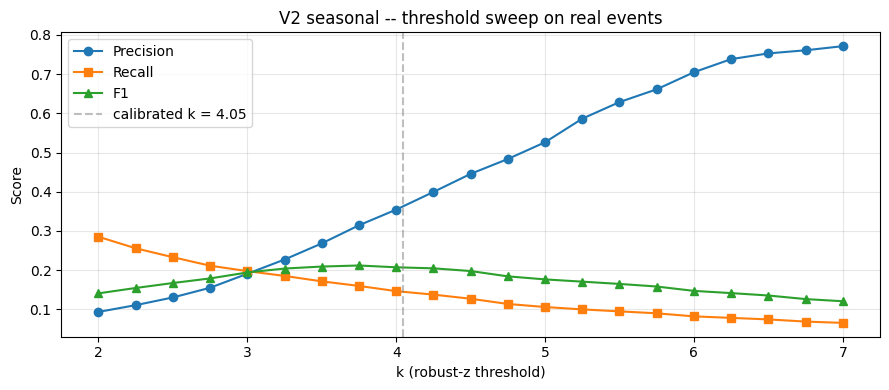

,k,precision,recall,f1,flagged
0,2.00,0.093489,0.285080,0.140803,0.065829
1,2.25,0.110684,0.255685,0.154491,0.049868
2,2.50,0.130354,0.232945,0.167164,0.038578
3,2.75,0.155067,0.211314,0.178873,0.029418
4,3.00,0.190782,0.197449,0.194058,0.022342
5,3.25,0.227056,0.185247,0.204032,0.017613
6,3.50,0.268229,0.171381,0.209137,0.013793
7,3.75,0.314410,0.159734,0.211843,0.010967
8,4.00,0.354362,0.146423,0.207221,0.008920
9,4.25,0.399356,0.137549,0.204620,0.007435


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

mask = df["scored"].to_numpy()
y_true = df["in_real_event"].to_numpy()[mask]
scores = df["robust_z"].to_numpy()[mask]

# Range widened from V1's [2.5, 6.0] because V2's median-of-medians
# narrows the baseline relative to V1's median-of-raw-minutes, giving
# heavier-tailed score distributions.
k_max = max(7.0, np.ceil(K_CALIBRATED + 1.0))
ks = np.arange(2.0, k_max + 0.01, 0.25)
rows = []
for k in ks:
    yp = scores > k
    rows.append({
        "k":         round(float(k), 2),
        "precision": precision_score(y_true, yp, zero_division=0),
        "recall":    recall_score(y_true, yp, zero_division=0),
        "f1":        f1_score(y_true, yp, zero_division=0),
        "flagged":   yp.mean(),
    })
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep["k"], sweep["precision"], marker="o", label="Precision")
ax.plot(sweep["k"], sweep["recall"],    marker="s", label="Recall")
ax.plot(sweep["k"], sweep["f1"],        marker="^", label="F1")
ax.axvline(K_CALIBRATED, color="grey", linestyle="--", alpha=0.5,
           label=f"calibrated k = {K_CALIBRATED:.2f}")
ax.set_xlabel("k (robust-z threshold)"); ax.set_ylabel("Score")
ax.set_title("V2 seasonal -- threshold sweep on real events")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

sweep


## 9. Timeline visualization

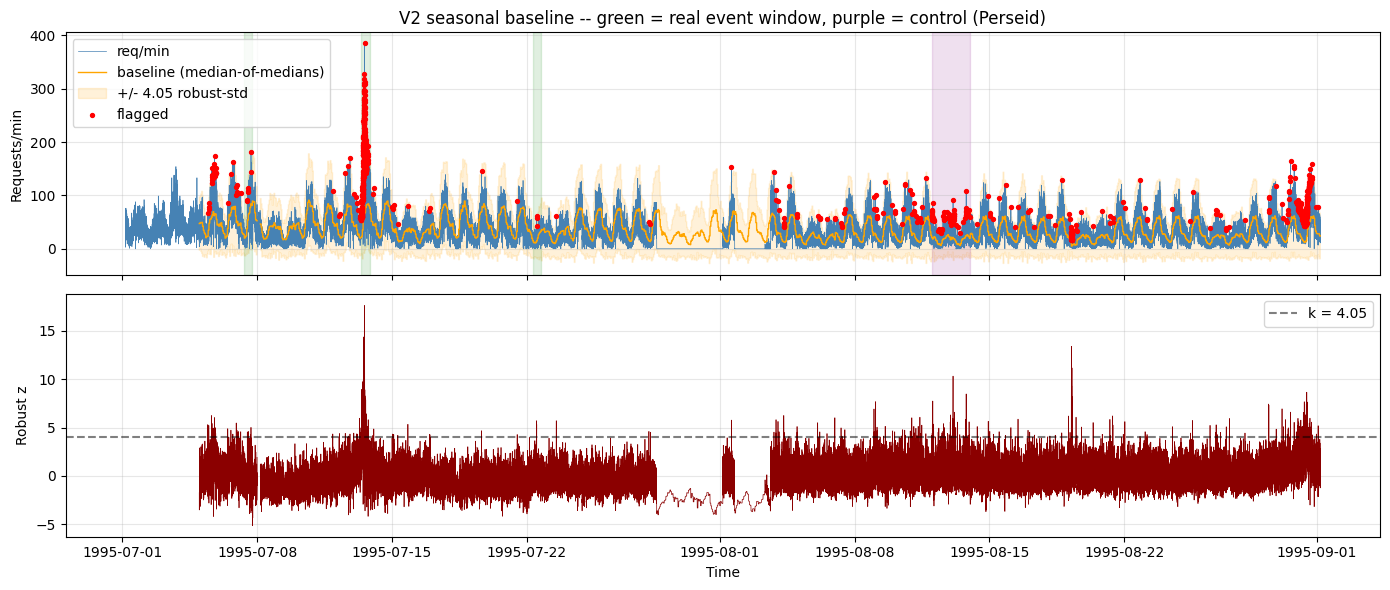

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df["timestamp"], df["value"], lw=0.5, color="steelblue", label="req/min")
ax1.plot(df["timestamp"], df["baseline_median"], lw=1.0, color="orange",
         label="baseline (median-of-medians)")

# Band: K * 0.7413 * floored_IQR (analog of V1's K * 1.4826 * MAD)
scale_for_band = df["baseline_scale"].clip(lower=SCALE_FLOOR)
ax1.fill_between(df["timestamp"],
                 df["baseline_median"] - K_CALIBRATED * 0.7413 * scale_for_band,
                 df["baseline_median"] + K_CALIBRATED * 0.7413 * scale_for_band,
                 alpha=0.15, color="orange",
                 label=f"+/- {K_CALIBRATED:.2f} robust-std")

flagged = df[df["flag_seasonal"]]
ax1.scatter(flagged["timestamp"], flagged["value"],
            color="red", s=8, zorder=5, label="flagged")

for _, e in EVENTS.iterrows():
    color = "green" if e["class"] == "real" else "purple"
    ax1.axvspan(e["start"], e["end"], alpha=0.12, color=color)

ax1.set_ylabel("Requests/min")
ax1.legend(loc="upper left"); ax1.grid(alpha=0.3)
ax1.set_title("V2 seasonal baseline -- green = real event window, purple = control (Perseid)")

ax2.plot(df["timestamp"], df["robust_z"], lw=0.5, color="darkred")
ax2.axhline(K_CALIBRATED, color="black", linestyle="--", alpha=0.5,
            label=f"k = {K_CALIBRATED:.2f}")
ax2.set_ylabel("Robust z"); ax2.set_xlabel("Time")
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()


## 10. Export flags for ensemble integration

Output paths use a `_v2` suffix so this notebook does not silently overwrite the V1 standalone's exports.

In [13]:
flags_path  = OUT_DIR / "uc1_flags_seasonal_v2.csv"
config_path = OUT_DIR / "uc1_seasonal_v2_config.json"

(df[["timestamp", "robust_z", "flag_seasonal"]]
    .to_csv(flags_path, index=False))

config = {
    "detector_version":   "V2-weekend",
    "storage":            "hourly summary buffer (per-hour median + IQR)",
    "window_days":        WINDOW_DAYS,
    "min_samples":        MIN_SAMPLES,
    "target_fpr":         TARGET_FPR,
    "k_calibrated":       K_CALIBRATED,
    "achieved_benign_fpr": achieved_fpr,
    "events_covered":     events_covered,
    "events_total":       len(REAL_EVENTS),
    "perseid_hit_rate":   float(ctrl_hit),
    "scale_floor":        SCALE_FLOOR,
    "pooling":            POOLING,
    "bucket_spec":        "hour_of_day x is_weekend (48 buckets)",
    "stats":              "median-of-medians + 0.7413 * median-of-IQRs (robust z)",
    "iqr_to_sigma":       0.7413,
    "events":             [{"name": r["name"], "start": str(r["start"]),
                            "end": str(r["end"]), "class": r["class"]}
                           for _, r in EVENTS.iterrows()],
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Wrote {flags_path}")
print(f"Wrote {config_path}")


Wrote outputs\uc1_flags_seasonal_v2.csv
Wrote outputs\uc1_seasonal_v2_config.json
